In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
import logging

# Set up logging to see our cleaner working
logging.basicConfig(level=logging.INFO)

# Add parent dir to path
sys.path.append(os.path.abspath('..'))

# IMPORT YOUR MODULES
from pricing_engine.causal_model import DML_ElasticityModel
from pricing_engine.data_loader import load_and_clean_seattle_data

# Module 01: Causal Identification & Validation
**Objective:** Prove that DML recovers a NEGATIVE price elasticity (Law of Demand) where naive correlation fails.

In [2]:
from pathlib import Path



try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()

# SCRIPT_DIR is the 'notebooks' folder.
# SCRIPT_DIR.parent is the 'Dynamic Pricing Engine' folder.
PROJECT_ROOT = SCRIPT_DIR.parent

# Now build the path from the project root
CALENDAR_PATH = PROJECT_ROOT / 'data' / 'calendar.csv'
LISTINGS_PATH = PROJECT_ROOT / 'data' / 'listings.csv'



In [3]:
# Load raw CSVs (optimize types if files are huge)
print("Loading raw CSVs...")
df_cal = pd.read_csv(CALENDAR_PATH)
df_list = pd.read_csv(LISTINGS_PATH)

print(f"Calendar Rows: {len(df_cal)}")
print(f"Listings Rows: {len(df_list)}")

Loading raw CSVs...
Calendar Rows: 1393570
Listings Rows: 3818


In [4]:
df_final = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)

INFO:PriceEngine_Loader:Loading raw data...
INFO:PriceEngine_Loader:Recovered prices. Kept 1393570 / 1393570 rows.
INFO:PriceEngine_Loader:Total Booked Nights Recovered: 459028


In [5]:
print(df_final[['price', 'is_booked', 'neighborhood']].head())
print(f"Mean Price: ${df_final['price'].mean():.2f}")

   price  is_booked    neighborhood
0  120.0          1  Rainier Valley
1  120.0          1  Rainier Valley
2  120.0          1  Rainier Valley
3  120.0          1  Rainier Valley
4  120.0          1  Rainier Valley
Mean Price: $135.62


In [6]:
df_final['is_booked'].value_counts()

is_booked
0    934542
1    459028
Name: count, dtype: int64

## 2. Feature Engineering
We define $X$ (Confounders), $T$ (Log Price), and $Y$ (Booking).

In [7]:
# Ensure date features
df_final['date'] = pd.to_datetime(df_final['date'])
df_final['day_of_year'] = df_final['date'].dt.dayofyear
df_final['dow'] = df_final['date'].dt.dayofweek
df_final['month'] = df_final['date'].dt.month
df_final['is_weekend'] = (df_final['dow'] >= 5).astype(int)

In [8]:
enc = OrdinalEncoder()
# Fill NaN neighborhoods to avoid errors
df_final['neighborhood'] = df_final['neighborhood'].fillna('Unknown')
df_final['neighborhood_enc'] = enc.fit_transform(df_final[['neighborhood']])

In [9]:
# DEFINE VECTORS
# X: The Confounders (What affects both price and demand?)
X_cols = ['day_of_year', 'dow', 'month', 'is_weekend', 'neighborhood_enc']
X = df_final[X_cols].fillna(0)

# T: Treatment (Log Price)
# We use Log because elasticity is a percentage concept
# We add +1 to avoid log(0) errors (though price is usually > 0)
T = np.log1p(df_final['price'])

# Y: Outcome (Did it book?)
Y = df_final['is_booked']

print(f"Training Data Ready: {len(X)} samples.")

Training Data Ready: 1393570 samples.


## 3. The "Naive" Baseline (The Trap)
What happens if we just run a regression?

In [10]:
naive = LinearRegression()
naive.fit(T.values.reshape(-1, 1), Y)
naive_beta = naive.coef_[0]

print(f"Naive Elasticity: {naive_beta:.5f}")
if naive_beta > -0.01:
    print("⚠️  Naive model failed! It suggests price has little to no effect (or positive effect).")
    print("This confirms we need Causal Inference.")

Naive Elasticity: -0.02038


## 4. The Causal Solution (Double Machine Learning)
We now run the Orthogonal Learning process.

In [11]:
dml = DML_ElasticityModel(
    n_splits=3,
    n_bootstrap=60,
    random_state=42
)

dml.fit(X, T, Y)

res = dml.result
print(f"Causal Elasticity (beta): {res.elasticity:.5f}")
print(f"95% CI: [{res.ci_lower:.5f}, {res.ci_upper:.5f}]")
print(f"Std Error (bootstrap): {res.std_err:.5f}")
print(f"P-value (sign test): {res.p_value:.5f}")


INFO:PriceEngine_Causal:Training DML with 1393570 samples | 3-fold CV | 60 bootstrap draws
INFO:PriceEngine_Causal:Causal Elasticity: -0.0333 [-0.0371, -0.0301]


Causal Elasticity (beta): -0.03331
95% CI: [-0.03709, -0.03011]
Std Error (bootstrap): 0.00194
P-value (sign test): 0.00000


In [12]:
residuals = dml.residuals_

print("Residual price variation diagnostics:")
print("Var(T_res):", residuals['T_res'].var())
print("1% |T_res| quantile:", np.percentile(np.abs(residuals['T_res']), 1))

if np.percentile(np.abs(residuals['T_res']), 1) < 1e-4:
    raise RuntimeError("❌ STOP: Insufficient overlap after conditioning.")
else:
    print("✅ Overlap check passed.")


Residual price variation diagnostics:
Var(T_res): 0.30449009002232647
1% |T_res| quantile: 0.007134300258157644
✅ Overlap check passed.


In [16]:
# ------------------------------------
# FINAL VALID PLACEBO: Cross-listing price reassignment
# ------------------------------------

rng = np.random.default_rng(123)

df_placebo = df_final.copy()

# Randomly reassign prices ACROSS listings
df_placebo['price_placebo'] = rng.permutation(df_placebo['price'].values)

T_placebo = np.log1p(df_placebo['price_placebo'])

dml_placebo = DML_ElasticityModel(
    n_splits=3,
    n_bootstrap=30,
    random_state=999
)

dml_placebo.fit(X, T_placebo, Y)
res_p = dml_placebo.result

print("\n--- PLACEBO TEST (Cross-listing Random Price) ---")
print(f"Placebo Elasticity: {res_p.elasticity:.5f}")
print(f"95% CI: [{res_p.ci_lower:.5f}, {res_p.ci_upper:.5f}]")
print(f"P-value: {res_p.p_value:.5f}")

if res_p.ci_lower <= 0 <= res_p.ci_upper:
    print("✅ PLACEBO PASSED: No causal signal after destroying price identity.")
else:
    print("❌ PLACEBO FAILED.")


INFO:PriceEngine_Causal:Training DML with 1393570 samples | 3-fold CV | 30 bootstrap draws
INFO:PriceEngine_Causal:Causal Elasticity: -0.0010 [-0.0034, 0.0017]



--- PLACEBO TEST (Cross-listing Random Price) ---
Placebo Elasticity: -0.00095
95% CI: [-0.00340, 0.00171]
P-value: 0.86667
✅ PLACEBO PASSED: No causal signal after destroying price identity.


## 5. Visual Validation
We bin the residuals to visualize the clean demand curve.

C:\Users\99sma\AppData\Local\Temp\ipykernel_24584\3327623713.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = residuals.groupby('T_res_bin')[['T_res', 'Y_res']].mean()


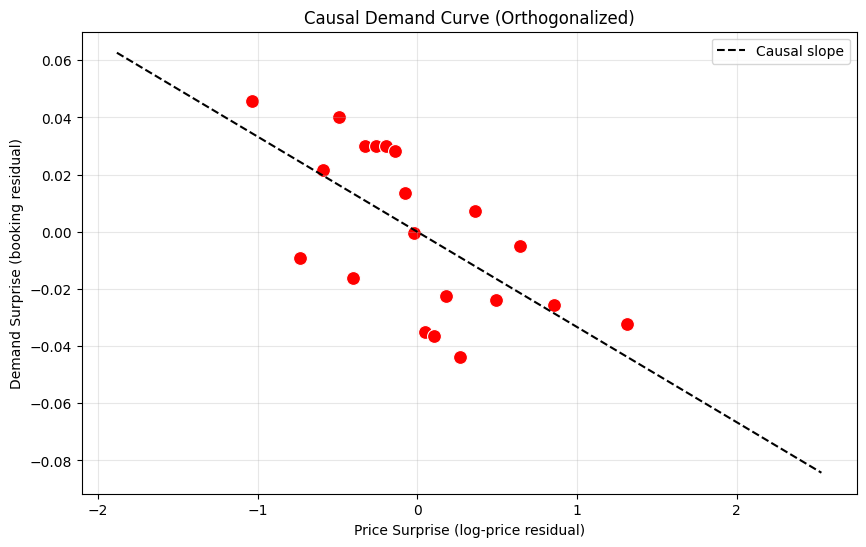

In [14]:
residuals = dml.residuals_.copy()
residuals['T_res_bin'] = pd.qcut(residuals['T_res'], q=20, duplicates='drop')

bin_stats = residuals.groupby('T_res_bin')[['T_res', 'Y_res']].mean()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='T_res',
    y='Y_res',
    data=bin_stats,
    s=100,
    color='red'
)

x = np.linspace(
    residuals['T_res'].min(),
    residuals['T_res'].max(),
    100
)
plt.plot(x, res.elasticity * x, '--k', label='Causal slope')

plt.title("Causal Demand Curve (Orthogonalized)")
plt.xlabel("Price Surprise (log-price residual)")
plt.ylabel("Demand Surprise (booking residual)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 6. Hard Stop Check

In [15]:
is_negative = res.elasticity < 0
is_significant = (res.ci_upper < 0)

print(f"Negative Slope? {is_negative}")
print(f"Statistically Significant? {is_significant}")

if is_significant:
    print("✅ PASS: Causal Identification Successful. Proceed to Module 02.")
else:
    print("❌ FAIL: Cannot verify Law of Demand. Check features or data quality.")

Negative Slope? True
Statistically Significant? True
✅ PASS: Causal Identification Successful. Proceed to Module 02.
